In [12]:
# ============================================================
# STEP 1: Load and Explore Dataset
# ============================================================
print("\nSTEP 1: Loading and Exploring the dataset.....")
import pandas as pd
import numpy as np

# Load Fake and Real news datasets
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

print('\n The Fake and Real csv files are imported')

# Display first few rows
print("\nFirst 3 rows of Fake News dataset: ")
display(fake.head(3))

print("\n First 3 rows of Real News dataset:")
display(real.head(3))

# Add Lables: 1 = Fake, 0 = Real 
fake["label"] = 1
real["label"] = 0

# Combine Datasets
df = pd.concat([fake, real])[["text", "label"]]

# Show dataset distribution
print("\nNumber of Fake vs Real samples:")
print(df["label"].value_counts())
print("\n0 = Real News, 1 = Fake News")


STEP 1: Loading and Exploring the dataset.....

 The Fake and Real csv files are imported

First 3 rows of Fake News dataset: 


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"



 First 3 rows of Real News dataset:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"



Number of Fake vs Real samples:
label
1    23481
0    21417
Name: count, dtype: int64

0 = Real News, 1 = Fake News


In [13]:
# ============================================================
# STEP 2: Text Preprocessing
# ============================================================

print("\nSTEP 2: Converting text to numerical features using TF-IDF.....")

from sklearn.feature_extraction.text import TfidfVectorizer

# TF_IDF Vectorization
vectorizer = TfidfVectorizer(max_features=3000, stop_words="english")
X = vectorizer.fit_transform(df["text"]).toarray()
y = df["label"].values

print("Text Successfully converted into numerical features !")
print("Feature matrix shape:", X.shape)


STEP 2: Converting text to numerical features using TF-IDF.....
Text Successfully converted into numerical features !
Feature matrix shape: (44898, 3000)


In [14]:
# ============================================================
# STEP 3: Split Dataset
# ============================================================

print("\nSTEP 3: Splitting dataset into training and testing sets(80/20).....")

from sklearn.model_selection import train_test_split
import torch

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

# Convert to pyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

print( f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")


STEP 3: Splitting dataset into training and testing sets(80/20).....
Training samples: 35918, Testing samples: 8980


In [15]:
# ============================================================
# STEP 4: Build Feedforward Neural Network
# ============================================================

print("\nSTEP 4: Creating the Neural Network....")

import torch.nn as nn 

class FakeNewsNN(nn.Module):
    def __init__(self, input_size):
        super(FakeNewsNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64,1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x
input_size = X_train.shape[1]
model = FakeNewsNN(input_size)

print("Neural network architecture")
print(model)


STEP 4: Creating the Neural Network....
Neural network architecture
FakeNewsNN(
  (fc1): Linear(in_features=3000, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)



STEP 5: Training the neural network...


C:\Users\user\AppData\Local\Temp\ipykernel_720\1375694759.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_720\1375694759.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)


Epoch 1/15 - Loss: 0.6951
Epoch 2/15 - Loss: 0.6930
Epoch 3/15 - Loss: 0.6905
Epoch 4/15 - Loss: 0.6872
Epoch 5/15 - Loss: 0.6829
Epoch 6/15 - Loss: 0.6779
Epoch 7/15 - Loss: 0.6724
Epoch 8/15 - Loss: 0.6662
Epoch 9/15 - Loss: 0.6594
Epoch 10/15 - Loss: 0.6519
Epoch 11/15 - Loss: 0.6436
Epoch 12/15 - Loss: 0.6346
Epoch 13/15 - Loss: 0.6249
Epoch 14/15 - Loss: 0.6145
Epoch 15/15 - Loss: 0.6035


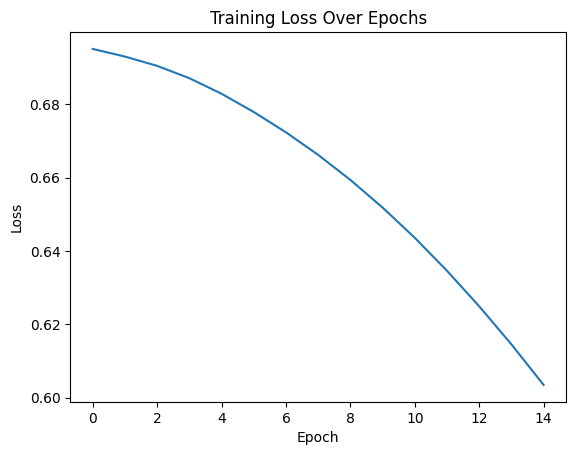

In [16]:
# ============================================================
# STEP 5: Train the Model
# ============================================================

print("\nSTEP 5: Training the neural network...")

import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# --- Convert training data to PyTorch tensors ---
# X_train: shape (num_samples, num_features), type float
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

# y_train: reshape to (num_samples, 1) and convert to float
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

# --- Loss function and optimizer ---
criterion = nn.BCELoss()  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Training loop ---
epochs = 15
losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    
    # Compute loss
    loss = criterion(outputs, y_train_tensor)
    
    # Backpropagation and weight update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Store loss for plotting
    losses.append(loss.item())
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

# --- Plot training loss ---
plt.plot(losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [18]:
# ============================================================
# STEP 6: Evaluate the Model
# ============================================================

print("\nSTEP 6: Evaluating model accuracy and performance...")

import torch
from sklearn.metrics import accuracy_score, confusion_matrix

# Convert test data to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)

# Set the model to evaluation mode
model.eval()

with torch.no_grad():
    # Forward pass on test data
    predictions = model(X_test_tensor)
    
    # Compute loss on test data
    criterion = nn.BCELoss()
    test_loss = criterion(predictions, y_test_tensor).item()
    
    # Convert probabilities to binary predictions (0 or 1)
    predicted_classes = (predictions > 0.5).float()

# Convert tensors back to NumPy arrays for sklearn metrics
y_test_np = y_test_tensor.numpy()
predicted_np = predicted_classes.numpy()

# Compute accuracy and confusion matrix
accuracy = accuracy_score(y_test_np, predicted_np)
cm = confusion_matrix(y_test_np, predicted_np)

print(f"Test Loss: {test_loss:.4f}")
print(f"Model Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(cm)


STEP 6: Evaluating model accuracy and performance...
Test Loss: 0.5931
Model Accuracy: 0.9194
Confusion Matrix:
[[3870  377]
 [ 347 4386]]


C:\Users\user\AppData\Local\Temp\ipykernel_720\1512808032.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_720\1512808032.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)
